# HCAV - jobrate dataset

In [1]:
# disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## jobrate dataset

In [2]:
# poison dataset
from clustvartools.datasets import jobrate
data = jobrate.data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Communication_Skills              103 non-null    int64
 1   Problem_Solving                   103 non-null    int64
 2   Learning_Ability                  103 non-null    int64
 3   Judgement_under_Pressure          103 non-null    int64
 4   Observational_Skills              103 non-null    int64
 5   Willingness_to_Confront_Problems  103 non-null    int64
 6   Interest_in_People                103 non-null    int64
 7   Interpersonal_Sensitivity         103 non-null    int64
 8   Desire_for_Self_Improvement       103 non-null    int64
 9   Appearance                        103 non-null    int64
 10  Dependability                     103 non-null    int64
 11  Physical_Ability                  103 non-null    int64
 12  Integrity                         103 non-null 

## Instanciation and training

In [3]:
# instanciation
from clustvartools import HCAV
clf = HCAV(ncl=4,linkage="ward",sup_var=13)

### `fit` function

In [4]:
# fit function
clf.fit(data)

,ncl,4
,linkage,'ward'
,sup_var,13
,method,'pearson'
,metric,<function HCA...00230D26CE980>
Name,Type,Value
call_,call,call(Xtot= ...rall_Rating'])
quanti_var_,quanti_var,quanti_var(cl... 0.567593 )
quanti_var_sup_,quanti_var_sup,quanti_var_su... 0.995612)


### `fit_transform` function

In [5]:
# fit_transform function - distance
dist = clf.fit_transform(data)
dist

,1,2,3,4
Communication_Skills,0.656008,0.402714,0.697987,0.615562
Problem_Solving,0.684731,0.390794,0.732389,0.623119
Learning_Ability,0.723467,0.631668,0.552054,0.630321
Judgement_under_Pressure,0.595234,0.404415,0.738189,0.637206
Observational_Skills,0.717989,0.668549,0.515606,0.604220
Willingness_to_Confront_Problems,0.727934,0.657926,0.542639,0.583063
Interest_in_People,0.314986,0.649668,0.761713,0.629915
Interpersonal_Sensitivity,0.328744,0.638046,0.788366,0.647168
Desire_for_Self_Improvement,0.656693,0.653495,0.544864,0.607079
Appearance,0.709886,0.691738,0.742775,0.308053


### `transform` function

In [6]:
# transform function
dist = clf.transform(jobrate.actif)
dist

,1,2,3,4
Communication_Skills,0.656008,0.402714,0.697987,0.615562
Problem_Solving,0.684731,0.390794,0.732389,0.623119
Learning_Ability,0.723467,0.631668,0.552054,0.630321
Judgement_under_Pressure,0.595234,0.404415,0.738189,0.637206
Observational_Skills,0.717989,0.668549,0.515606,0.604220
Willingness_to_Confront_Problems,0.727934,0.657926,0.542639,0.583063
Interest_in_People,0.314986,0.649668,0.761713,0.629915
Interpersonal_Sensitivity,0.328744,0.638046,0.788366,0.647168
Desire_for_Self_Improvement,0.656693,0.653495,0.544864,0.607079
Appearance,0.709886,0.691738,0.742775,0.308053


### `fit_predict` function

In [7]:
# fit_predict function
prediction = clf.fit_predict(data)
prediction.to_frame()

,cluster
Communication_Skills,2
Problem_Solving,2
Learning_Ability,3
Judgement_under_Pressure,2
Observational_Skills,3
Willingness_to_Confront_Problems,3
Interest_in_People,1
Interpersonal_Sensitivity,1
Desire_for_Self_Improvement,3
Appearance,4


### `predict` function

In [8]:
# predict function
prediction = clf.predict(jobrate.actif)
prediction.to_frame()

,cluster
Communication_Skills,2
Problem_Solving,2
Learning_Ability,3
Judgement_under_Pressure,2
Observational_Skills,3
Willingness_to_Confront_Problems,3
Interest_in_People,1
Interpersonal_Sensitivity,1
Desire_for_Self_Improvement,3
Appearance,4


In [9]:
# attributes
from clustvartools import sprintf
sprintf(clf)


**Clustering of Variables - HCAV**

*The results are available in the following objects:

name              description
----------------  --------------------------------------------------
.call_            summary called parameters
.quanti_var_      results for the continuous variables
.quanti_var_sup_  results for the supplementary continuous variables



## Variables informations

In [10]:
# variables informations
var_ = clf.quanti_var_
var_._fields

('cluster', 'dist', 'member')

### Cluster distance

In [11]:
# cluster distance
var_.dist

,1,2,3,4
Communication_Skills,0.656008,0.402714,0.697987,0.615562
Problem_Solving,0.684731,0.390794,0.732389,0.623119
Learning_Ability,0.723467,0.631668,0.552054,0.630321
Judgement_under_Pressure,0.595234,0.404415,0.738189,0.637206
Observational_Skills,0.717989,0.668549,0.515606,0.604220
Willingness_to_Confront_Problems,0.727934,0.657926,0.542639,0.583063
Interest_in_People,0.314986,0.649668,0.761713,0.629915
Interpersonal_Sensitivity,0.328744,0.638046,0.788366,0.647168
Desire_for_Self_Improvement,0.656693,0.653495,0.544864,0.607079
Appearance,0.709886,0.691738,0.742775,0.308053


### Cluster member

In [12]:
# cluster member
var_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,Ratio (Own/Next)
12,Integrity,1,0.347192,0.611693,0.567593
6,Interest_in_People,1,0.314986,0.629915,0.500045
7,Interpersonal_Sensitivity,1,0.328744,0.638046,0.515235
0,Communication_Skills,2,0.402714,0.615562,0.654222
3,Judgement_under_Pressure,2,0.404415,0.595234,0.679423
1,Problem_Solving,2,0.390794,0.623119,0.627158
10,Dependability,3,0.560192,0.585259,0.957169
8,Desire_for_Self_Improvement,3,0.544864,0.607079,0.897517
2,Learning_Ability,3,0.552054,0.630321,0.875829
4,Observational_Skills,3,0.515606,0.60422,0.853342


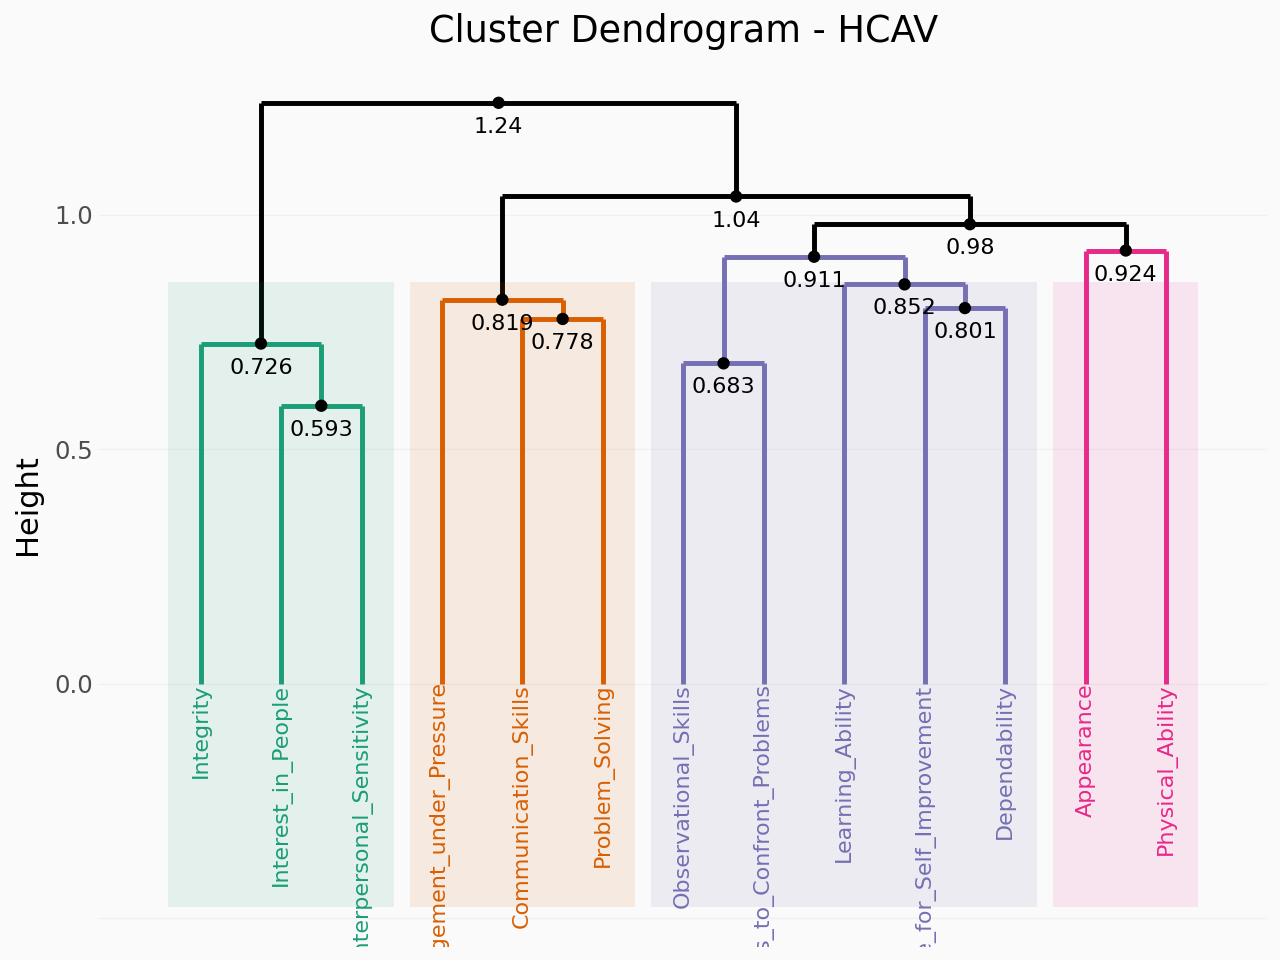

None


In [13]:
# dendrogram
from clustvartools import fviz_dend, fviz_height
p = fviz_dend(obj=clf,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_y=-0.03)
print(p.show())

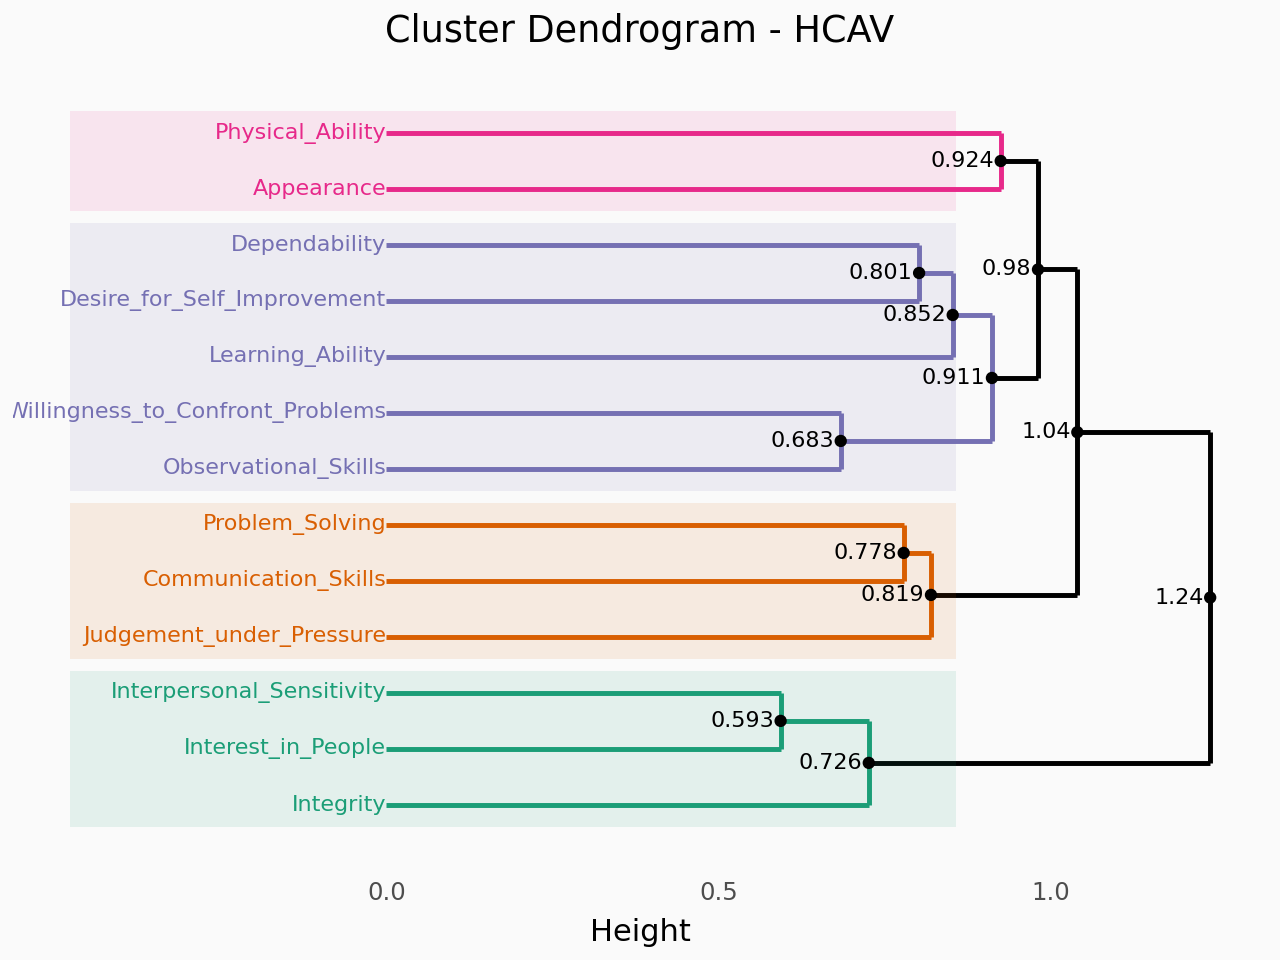

None


In [14]:
# horizon 
p = fviz_dend(obj=clf,
              horiz=True,
              rect=True,
              rect_fill=True,
              color_labels_by_cluster=True,
              text_size=8,
              text_height=True,
              nudge_x=-0.01)
print(p.show())

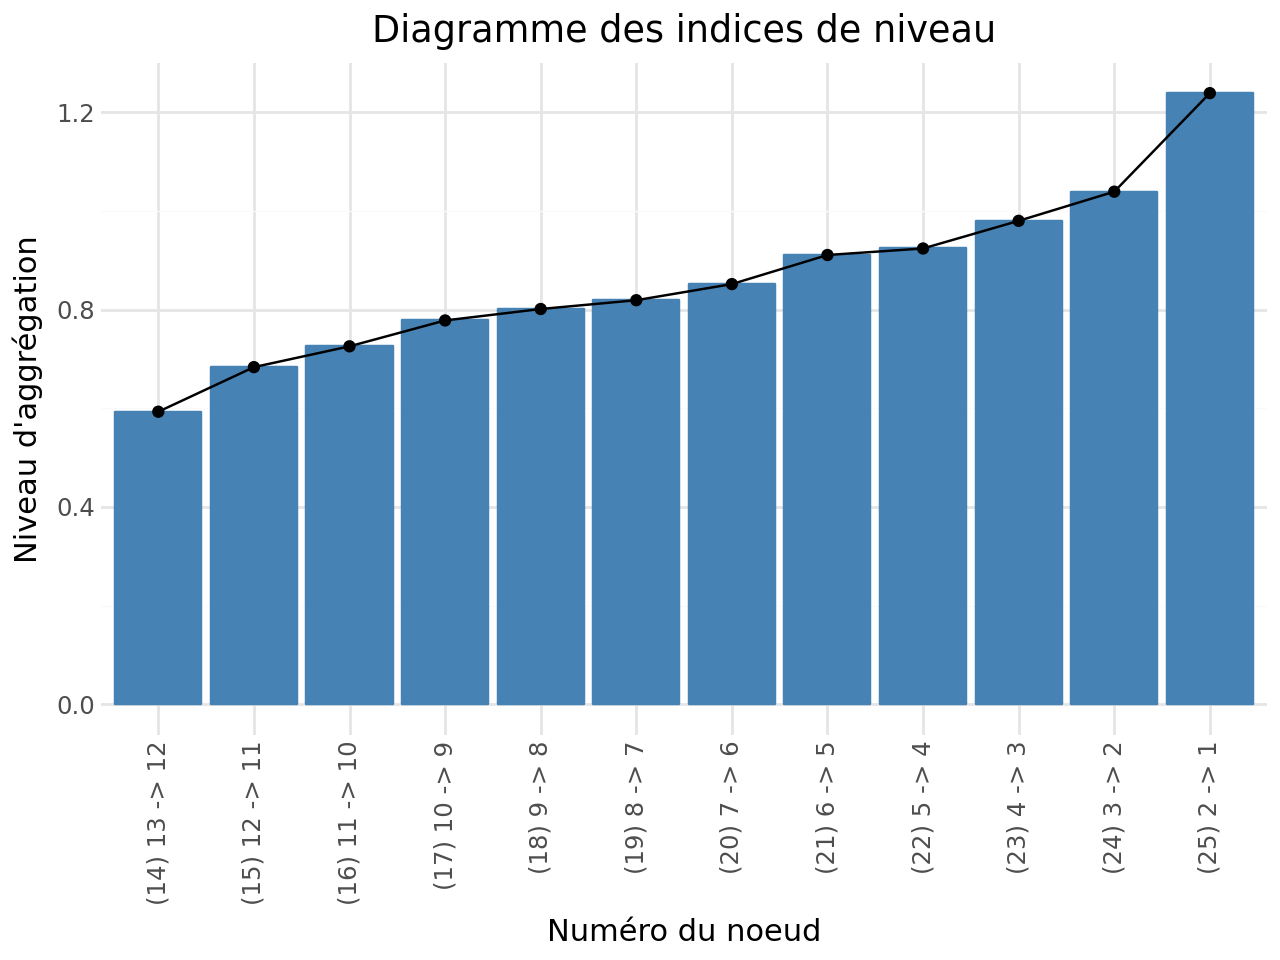

None


In [15]:
# graph of height
p = fviz_height(clf)
print(p.show())

## Supplementary variables informations

In [16]:
# supplementary variables informations
var_sup_ = clf.quanti_var_sup_
var_sup_._fields

('cluster', 'dist', 'member')

### Cluster

In [17]:
# cluster
var_sup_.cluster.to_frame()

,cluster
Overall_Rating,4


### Cluster distance

In [18]:
# cluster distance - supplementary variables
var_sup_.dist

,1,2,3,4
Overall_Rating,0.586814,0.576283,0.634764,0.573754


### Cluster member

In [19]:
# cluster member
var_sup_.member.sort_values(by=["Cluster","Variable"])

,Variable,Cluster,Own Cluster,Next Closest,Ratio (Own/Next)
0,Overall_Rating,4,0.573754,0.576283,0.995612


## Summary

In [20]:
# summary
from clustvartools import summary
summary(clf)

                     Clustering of Variables - HCAV Results                     

Cluster Distance:
                                       1       2       3       4
Communication_Skills              0.6560  0.4027  0.6980  0.6156
Problem_Solving                   0.6847  0.3908  0.7324  0.6231
Learning_Ability                  0.7235  0.6317  0.5521  0.6303
Judgement_under_Pressure          0.5952  0.4044  0.7382  0.6372
Observational_Skills              0.7180  0.6685  0.5156  0.6042
Willingness_to_Confront_Problems  0.7279  0.6579  0.5426  0.5831
Interest_in_People                0.3150  0.6497  0.7617  0.6299
Interpersonal_Sensitivity         0.3287  0.6380  0.7884  0.6472
Desire_for_Self_Improvement       0.6567  0.6535  0.5449  0.6071
Appearance                        0.7099  0.6917  0.7428  0.3081

Cluster Members and Distance values:
                           Variable Cluster Own Cluster Next Closest  \
0              Communication_Skills       2    0.402714     0.615562   
1  

In [21]:
# markdown formatting
summary(clf,to_markdown=True)

                     Clustering of Variables - HCAV Results                     

Cluster Distance:
                                       1       2       3       4
--------------------------------  ------  ------  ------  ------
Communication_Skills              0.656   0.4027  0.698   0.6156
Problem_Solving                   0.6847  0.3908  0.7324  0.6231
Learning_Ability                  0.7235  0.6317  0.5521  0.6303
Judgement_under_Pressure          0.5952  0.4044  0.7382  0.6372
Observational_Skills              0.718   0.6685  0.5156  0.6042
Willingness_to_Confront_Problems  0.7279  0.6579  0.5426  0.5831
Interest_in_People                0.315   0.6497  0.7617  0.6299
Interpersonal_Sensitivity         0.3287  0.638   0.7884  0.6472
Desire_for_Self_Improvement       0.6567  0.6535  0.5449  0.6071
Appearance                        0.7099  0.6917  0.7428  0.3081

Cluster Members and Distance values:
    Variable                            Cluster    Own Cluster    Next Closest    